In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
import seaborn as sns;sns.set()
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from datetime import datetime,time
from plotly.offline import iplot,plot,init_notebook_mode,download_plotlyjs
%matplotlib inline 
init_notebook_mode(connected=True)
import math
import import_ipynb
import missingno as msno
import os

In [2]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.power import TTestIndPower, TTestPower
import warnings
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score

# Suppress warnings
warnings.filterwarnings('ignore')

# Set visualization style consistent with previous tutorials
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [16]:
#old = 'c:\\Users\\Omar\\Desktop\\Omar_Files\\Python_Analysis\\Pepper_Prices_Analysis\\Pepper_Prices_Analysis'
#os.chdir(old)
#os.getcwd() 

In [3]:
import os
%pwd
os.chdir("../")
%pwd

'c:\\Users\\Omar\\Desktop\\Omar_Files\\Python_Analysis\\Pepper_Prices_Analysis\\Pepper_Prices_Analysis'

In [4]:
df=pd.read_csv('Data_Sets/actual_data.csv')
df=df[df["total_volume"]!=-1]
df.interpolate(method="linear",inplace=True,limit_direction="backward")

df['week_start_dt']=pd.to_datetime(df['week_start_dt'])
df['week_end_dt']=pd.to_datetime(df['week_end_dt'])

numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
boolean_cols=df.select_dtypes(include='bool').columns.tolist()
date_cols=df.select_dtypes(include='datetime').columns.tolist()

print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

numerical_cols : 
['vietnam_season', 'price', 'total_volume', 'brazil', 'india', 'vietnam', 'indonesia', 'china', 'jordan_max_price', 'jordan_min_price', 'demand', 'supply']
--------------------------------------------------
categorical_cols : 
['p_color']
--------------------------------------------------
boolean_cols : 
['brazil_season', 'indonesia_season', 'india_season', 'china_season']
--------------------------------------------------
date_cols : 
['week_start_dt', 'week_end_dt']


In [ ]:
from utils import (visualize_chi_square_test_detailed,
                  visualize_chi_square_test_general,
                  visualize_categorical_association_advanced)

### *chi_square_test details*


Chi-square test for brazil_season vs p_color:
Example: Testing association between brazil_season and p_color


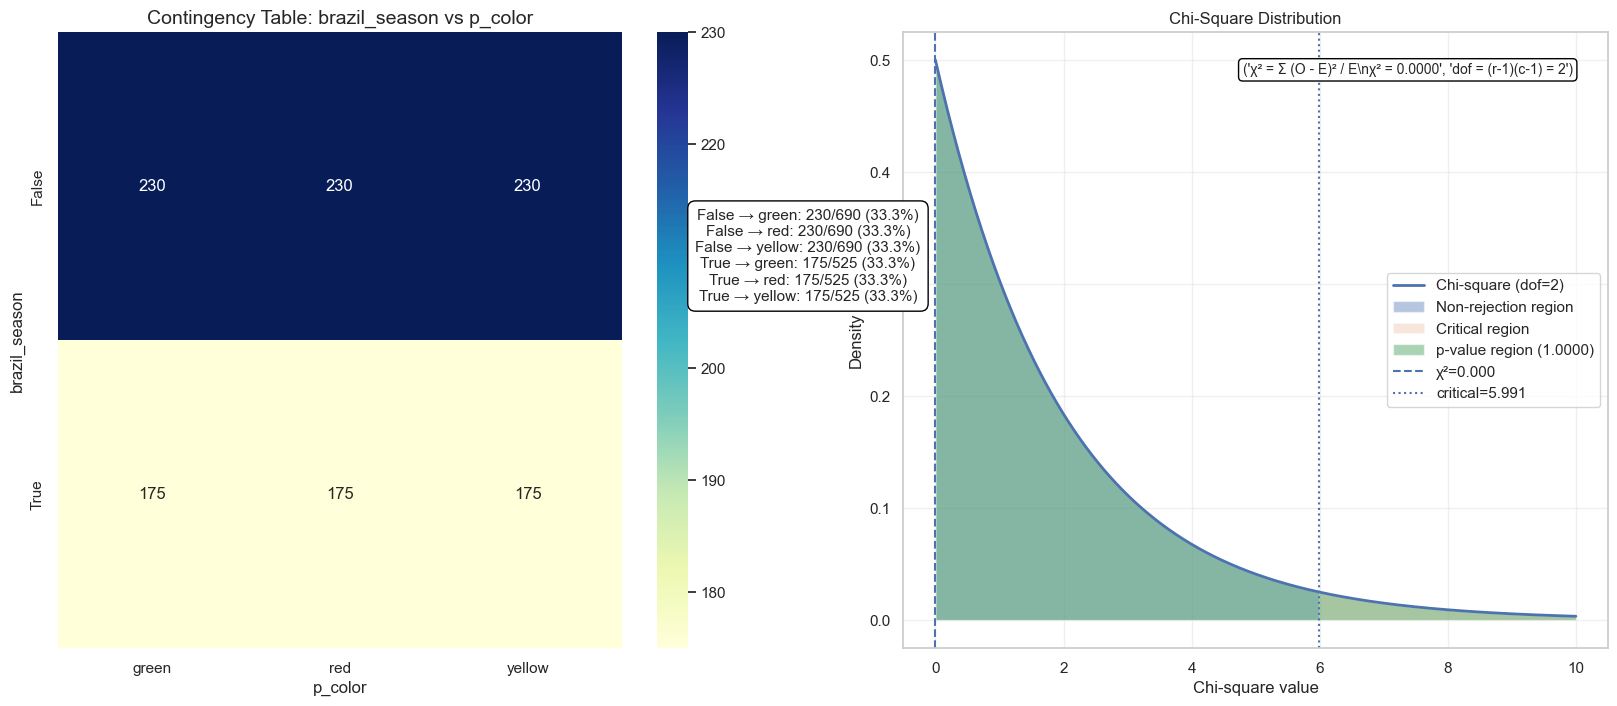


=== Chi-Square Test Summary ===

Observed:
p_color        green  red  yellow
brazil_season                    
False            230  230     230
True             175  175     175

Expected:
p_color        green    red  yellow
brazil_season                      
False          230.0  230.0   230.0
True           175.0  175.0   175.0

Row %:
p_color        green    red  yellow
brazil_season                      
False          33.33  33.33   33.33
True           33.33  33.33   33.33

χ² = 0.0000, dof = 2, p = 1.000000
→ Fail to reject H0 (no strong evidence of association)

--------------------------------------------------


Chi-square test for indonesia_season vs p_color:
Example: Testing association between indonesia_season and p_color


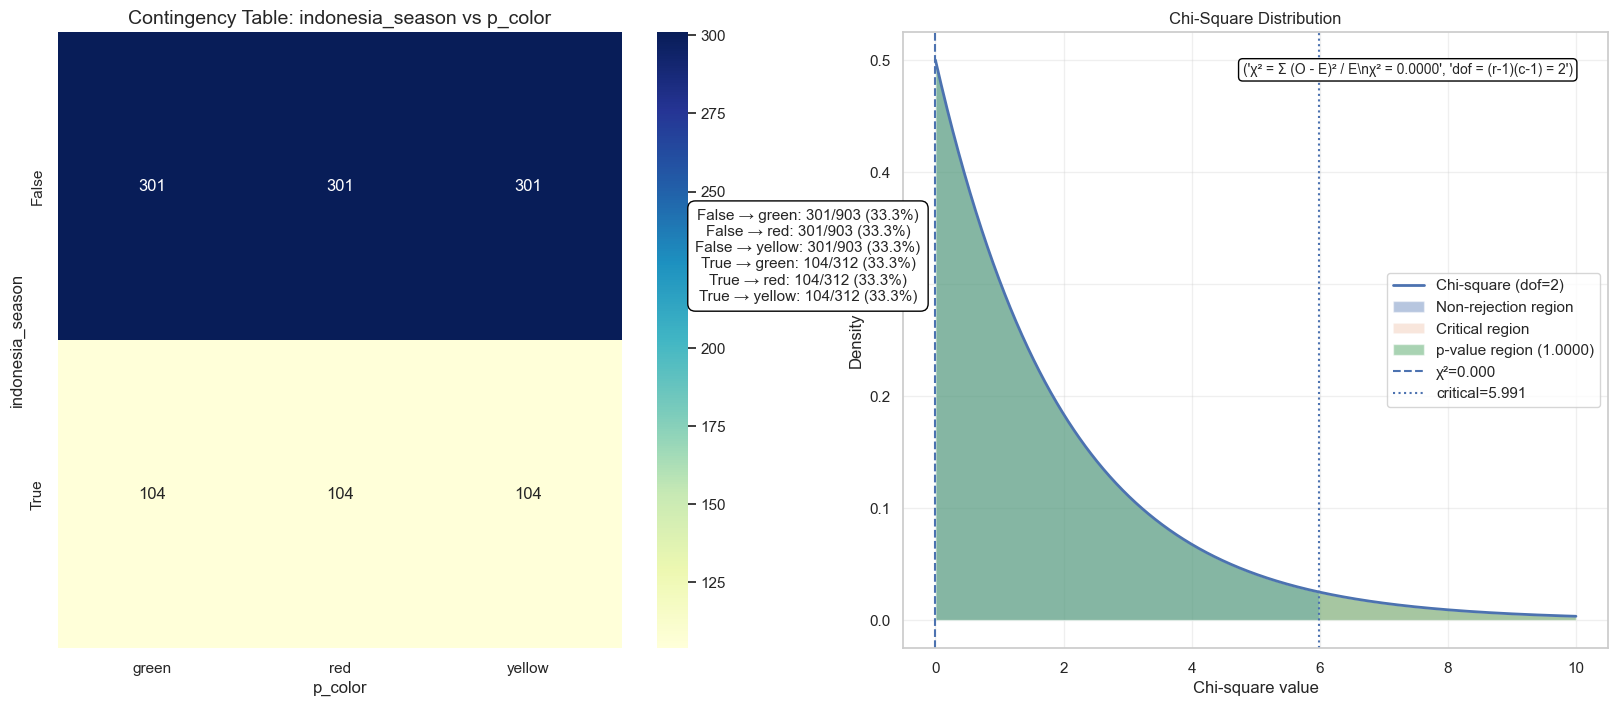


=== Chi-Square Test Summary ===

Observed:
p_color           green  red  yellow
indonesia_season                    
False               301  301     301
True                104  104     104

Expected:
p_color           green    red  yellow
indonesia_season                      
False             301.0  301.0   301.0
True              104.0  104.0   104.0

Row %:
p_color           green    red  yellow
indonesia_season                      
False             33.33  33.33   33.33
True              33.33  33.33   33.33

χ² = 0.0000, dof = 2, p = 1.000000
→ Fail to reject H0 (no strong evidence of association)

--------------------------------------------------


Chi-square test for india_season vs p_color:
Example: Testing association between india_season and p_color


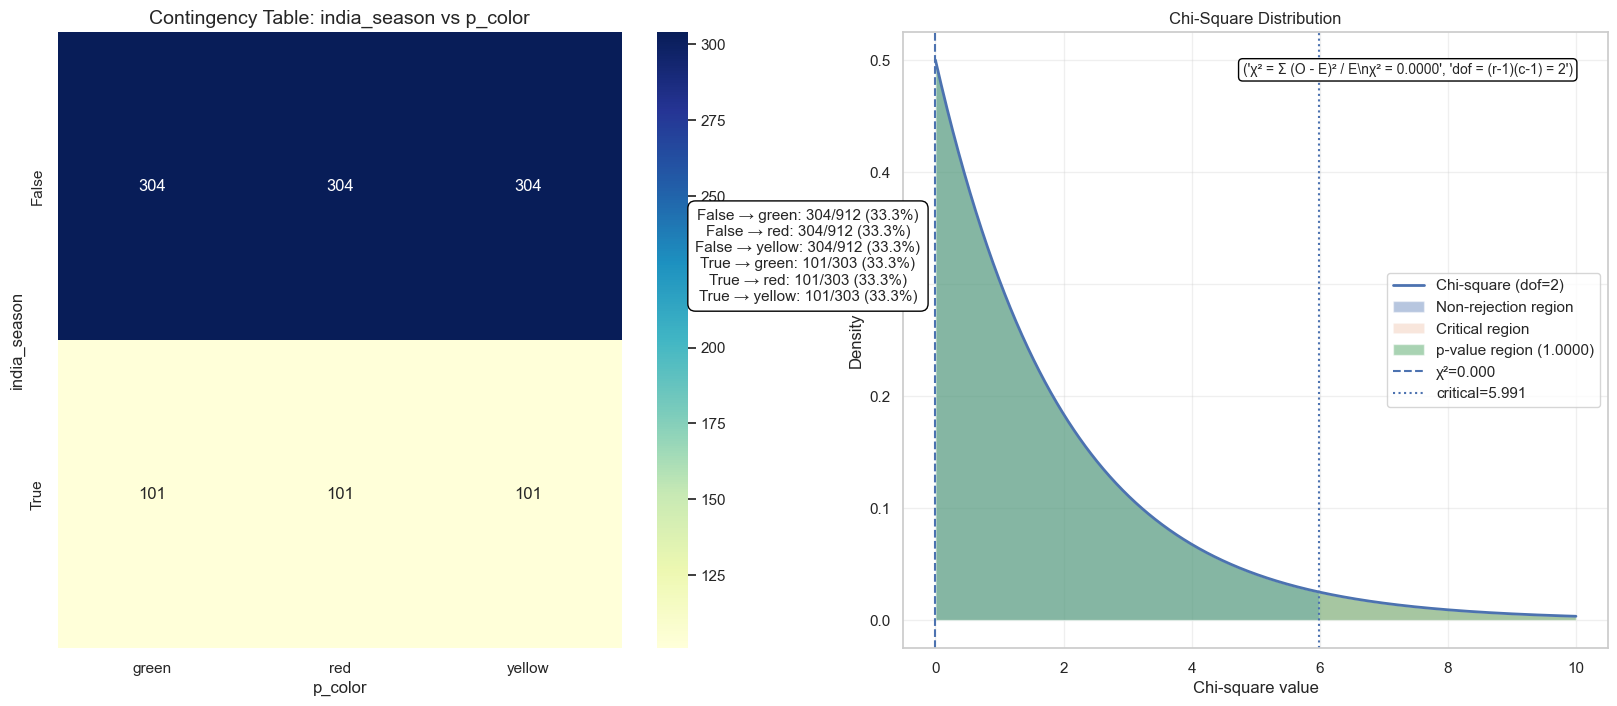


=== Chi-Square Test Summary ===

Observed:
p_color       green  red  yellow
india_season                    
False           304  304     304
True            101  101     101

Expected:
p_color       green    red  yellow
india_season                      
False         304.0  304.0   304.0
True          101.0  101.0   101.0

Row %:
p_color       green    red  yellow
india_season                      
False         33.33  33.33   33.33
True          33.33  33.33   33.33

χ² = 0.0000, dof = 2, p = 1.000000
→ Fail to reject H0 (no strong evidence of association)

--------------------------------------------------


Chi-square test for china_season vs p_color:
Example: Testing association between china_season and p_color


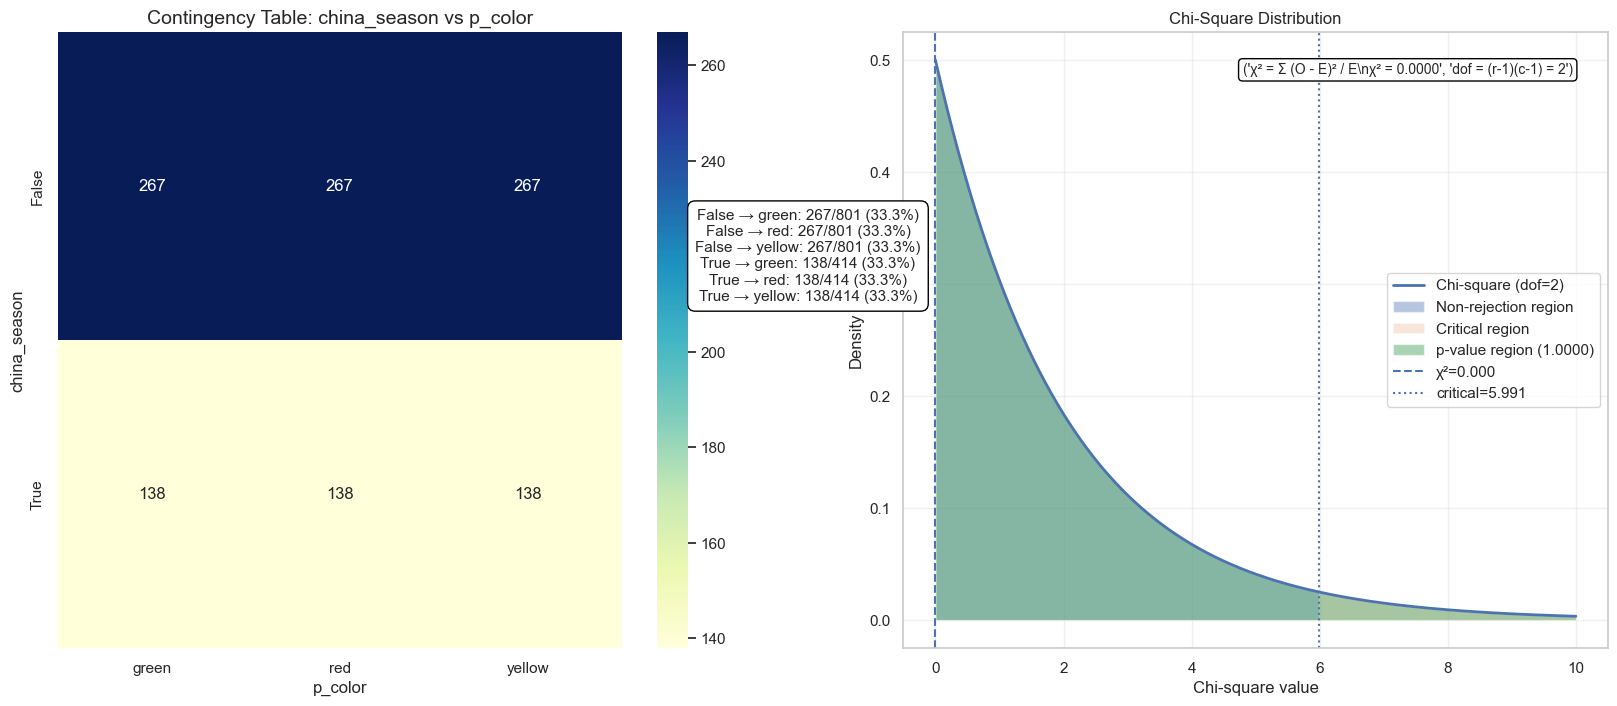


=== Chi-Square Test Summary ===

Observed:
p_color       green  red  yellow
china_season                    
False           267  267     267
True            138  138     138

Expected:
p_color       green    red  yellow
china_season                      
False         267.0  267.0   267.0
True          138.0  138.0   138.0

Row %:
p_color       green    red  yellow
china_season                      
False         33.33  33.33   33.33
True          33.33  33.33   33.33

χ² = 0.0000, dof = 2, p = 1.000000
→ Fail to reject H0 (no strong evidence of association)

--------------------------------------------------



In [9]:
df[boolean_cols]=df[boolean_cols].astype(str)
for col in boolean_cols:
    print(f"\nChi-square test for {col} vs p_color:")
    visualize_chi_square_test_detailed(df,col,"p_color", alpha=0.05)
    print("\n" + "-"*50 + "\n")

### *chi_square_test_general*

Example: Testing association between brazil_season and p_color


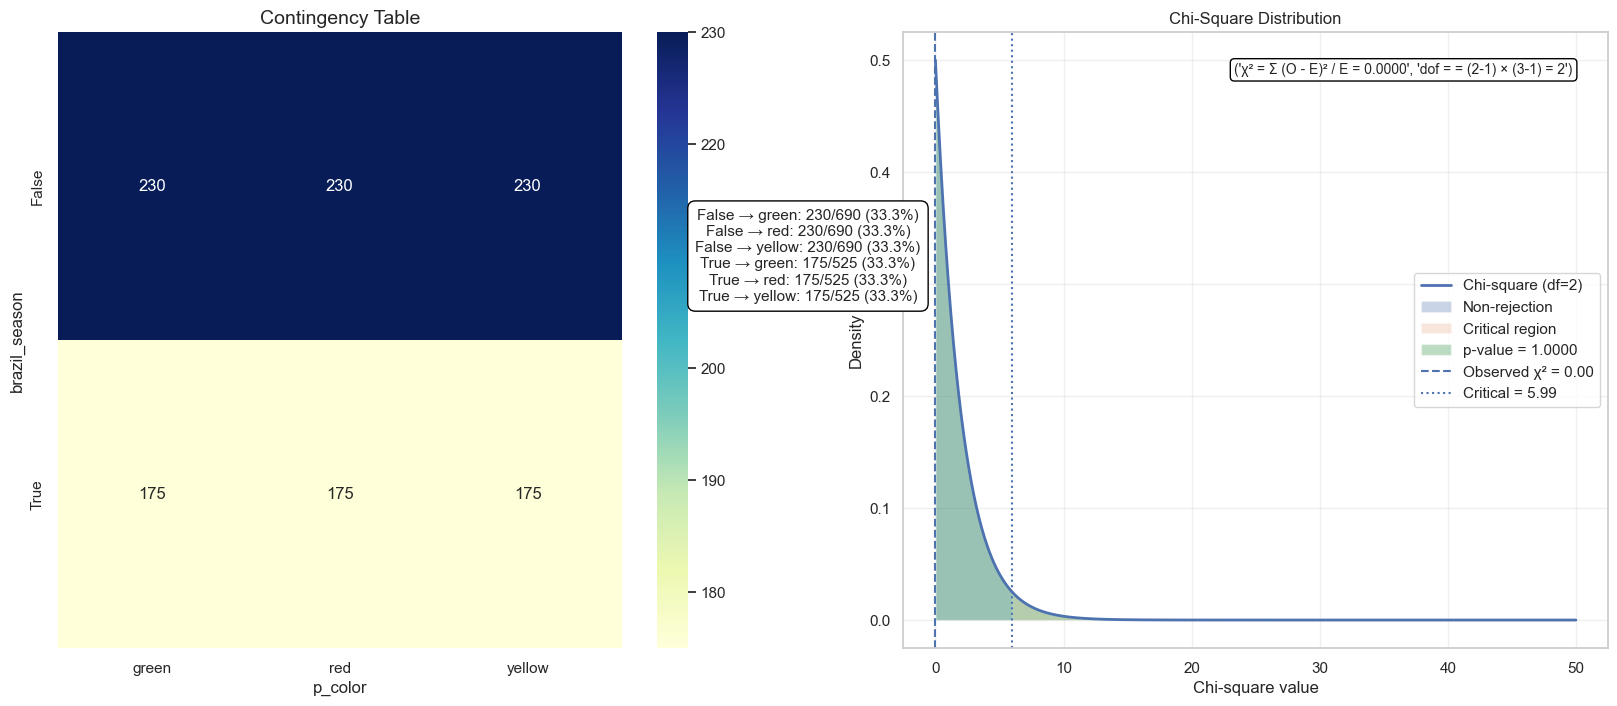


--- Chi-Square Test Summary ---
Chi-square: 0.0000
Degrees of freedom: 2
p-value: 1.000000

Observed:
p_color        green  red  yellow
brazil_season                    
False            230  230     230
True             175  175     175

Expected:
p_color        green    red  yellow
brazil_season                      
False          230.0  230.0   230.0
True           175.0  175.0   175.0

Row %:
p_color        green    red  yellow
brazil_season                      
False          33.33  33.33   33.33
True           33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: Fail to reject H0 (no significant association)
Example: Testing association between indonesia_season and p_color


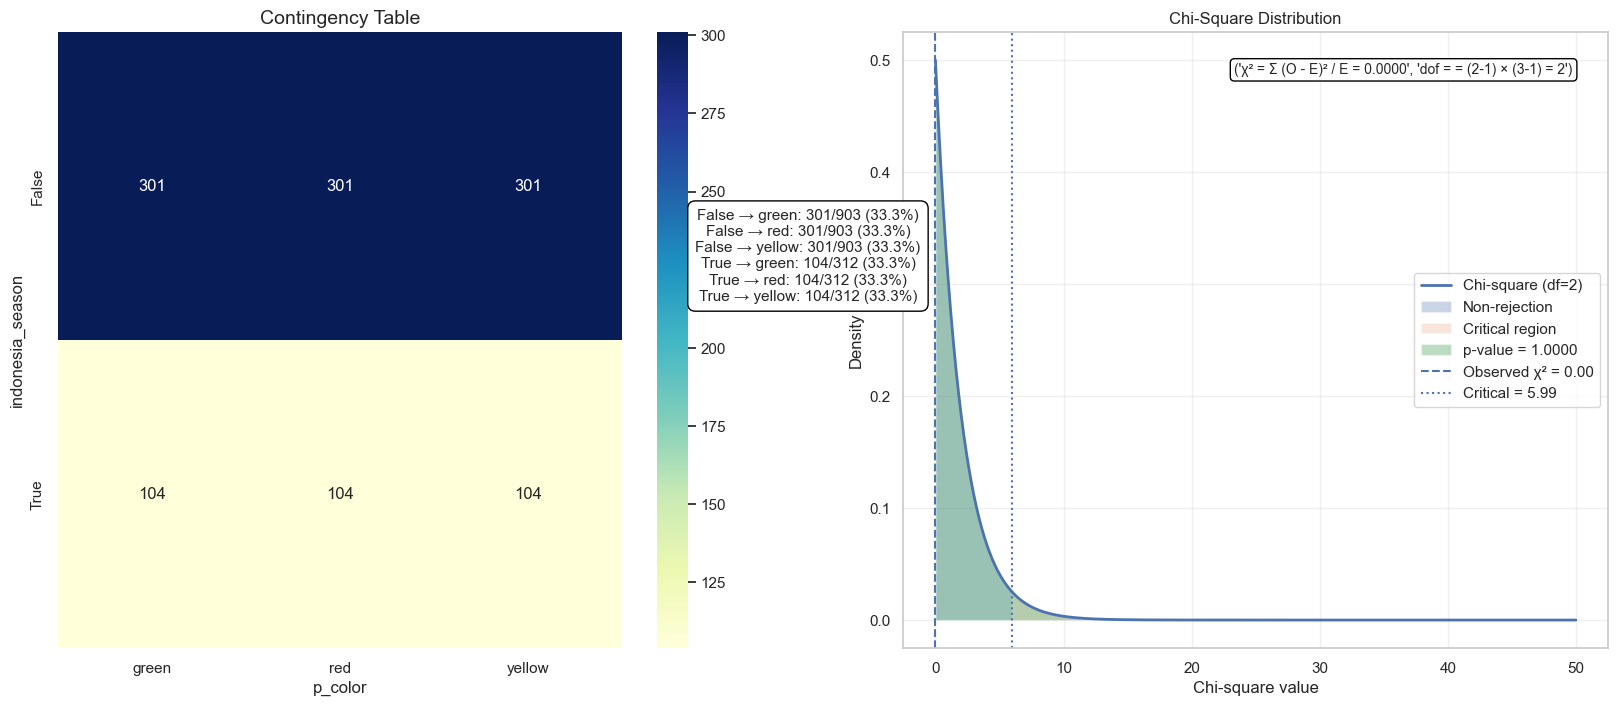


--- Chi-Square Test Summary ---
Chi-square: 0.0000
Degrees of freedom: 2
p-value: 1.000000

Observed:
p_color           green  red  yellow
indonesia_season                    
False               301  301     301
True                104  104     104

Expected:
p_color           green    red  yellow
indonesia_season                      
False             301.0  301.0   301.0
True              104.0  104.0   104.0

Row %:
p_color           green    red  yellow
indonesia_season                      
False             33.33  33.33   33.33
True              33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: Fail to reject H0 (no significant association)
Example: Testing association between india_season and p_color


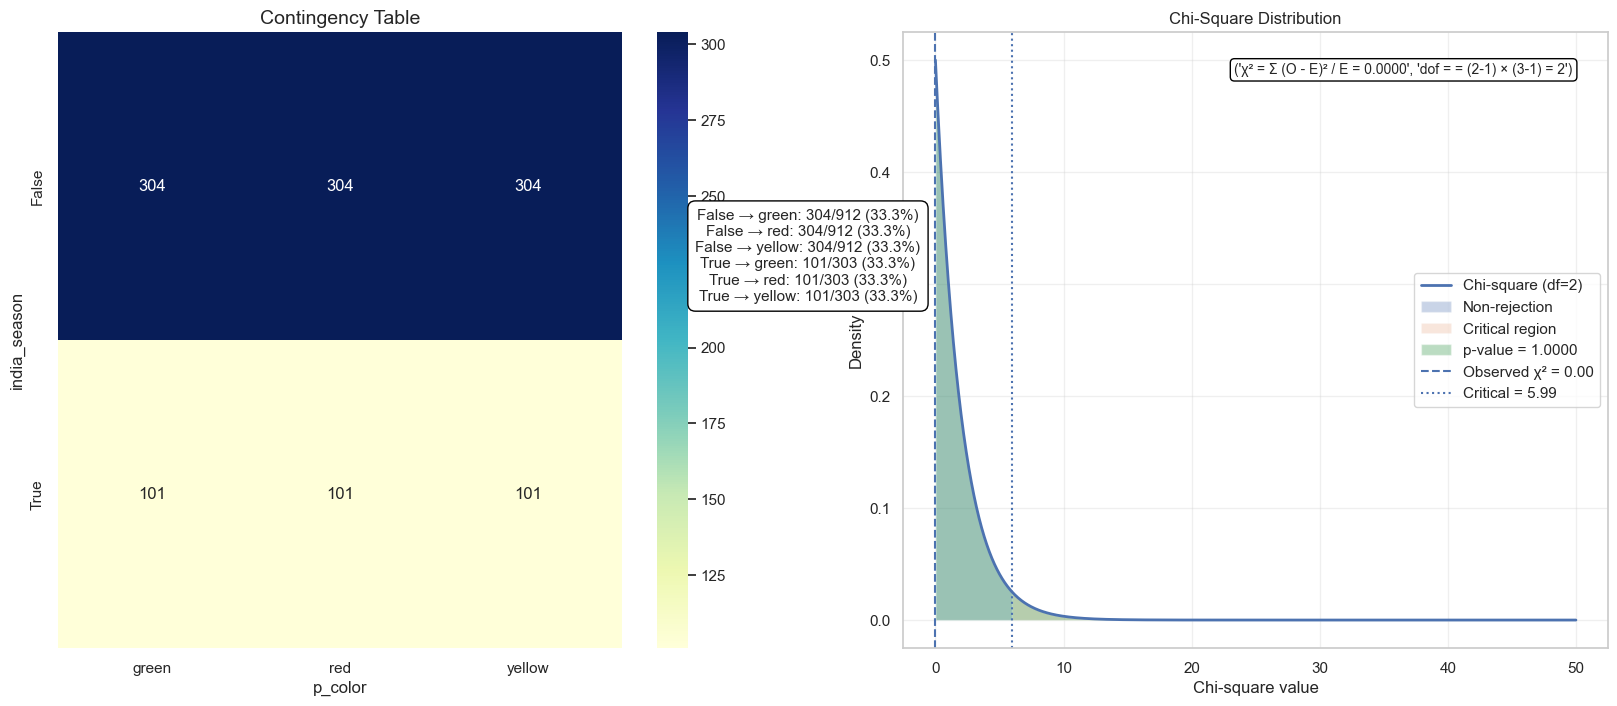


--- Chi-Square Test Summary ---
Chi-square: 0.0000
Degrees of freedom: 2
p-value: 1.000000

Observed:
p_color       green  red  yellow
india_season                    
False           304  304     304
True            101  101     101

Expected:
p_color       green    red  yellow
india_season                      
False         304.0  304.0   304.0
True          101.0  101.0   101.0

Row %:
p_color       green    red  yellow
india_season                      
False         33.33  33.33   33.33
True          33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: Fail to reject H0 (no significant association)
Example: Testing association between china_season and p_color


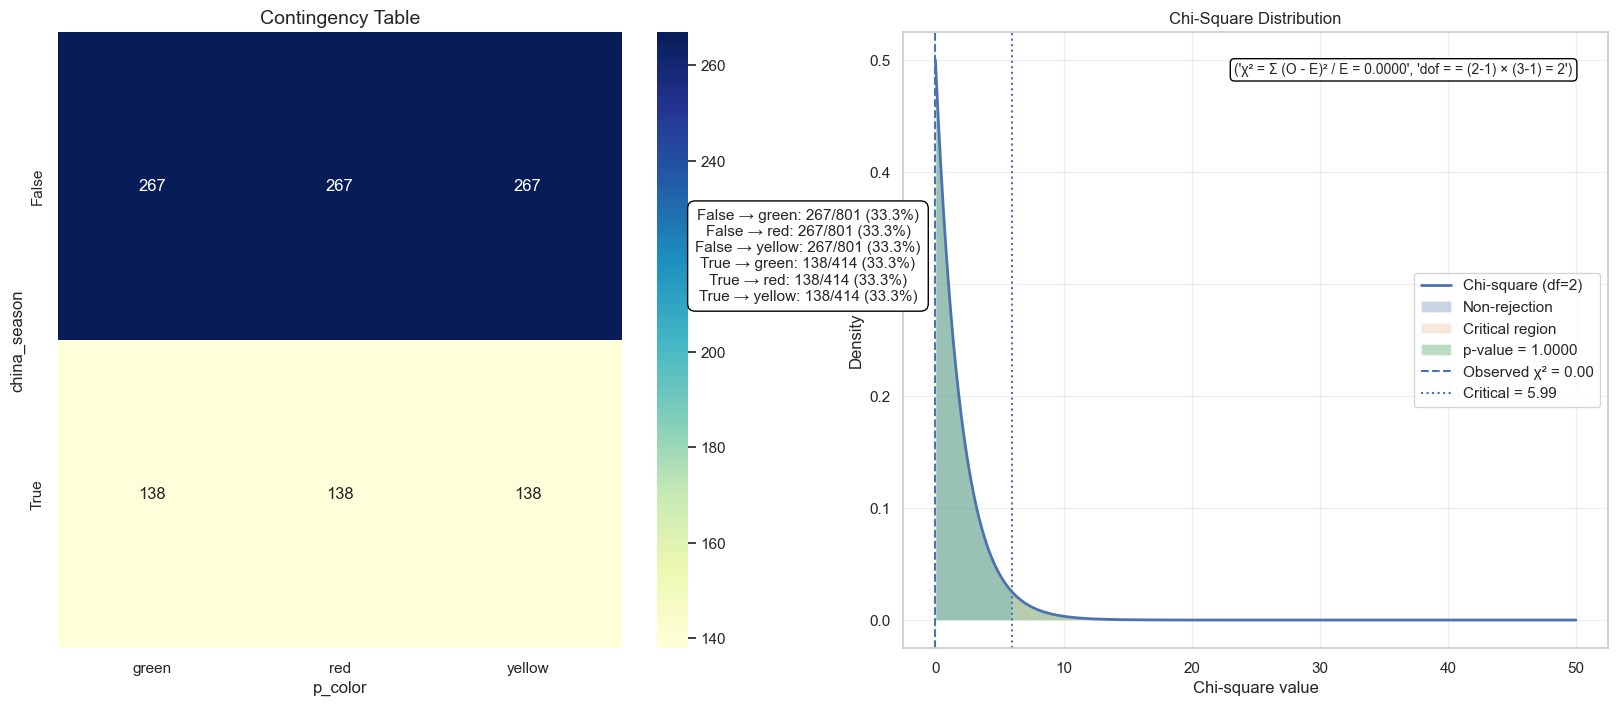


--- Chi-Square Test Summary ---
Chi-square: 0.0000
Degrees of freedom: 2
p-value: 1.000000

Observed:
p_color       green  red  yellow
china_season                    
False           267  267     267
True            138  138     138

Expected:
p_color       green    red  yellow
china_season                      
False         267.0  267.0   267.0
True          138.0  138.0   138.0

Row %:
p_color       green    red  yellow
china_season                      
False         33.33  33.33   33.33
True          33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: Fail to reject H0 (no significant association)


In [10]:
df[boolean_cols]=df[boolean_cols].astype(str)
for col in boolean_cols:
    visualize_chi_square_test_general(df,col,"p_color", alpha=0.05)

### *chi2 , carmer_V , Theil’s U*
* *chi2 --> if therelation exist or not (significant relationship or not)*
* *carmer V --> Tells how strong the raltion is (categorical “correlation coefficient)  ==> Interpretation (rule of thumb): 0.00–0.10 → weak,0.10–0.30 → moderate,0.30+ → strong*
* *Theil’s U (Uncertainty Coefficient) --> Measures predictive power Asymmetric: U(X → Y) ≠ U(Y → X) 👉 Useful when: You want to know “Does feature A help predict feature B?*

Analyzing association between brazil_season and p_color


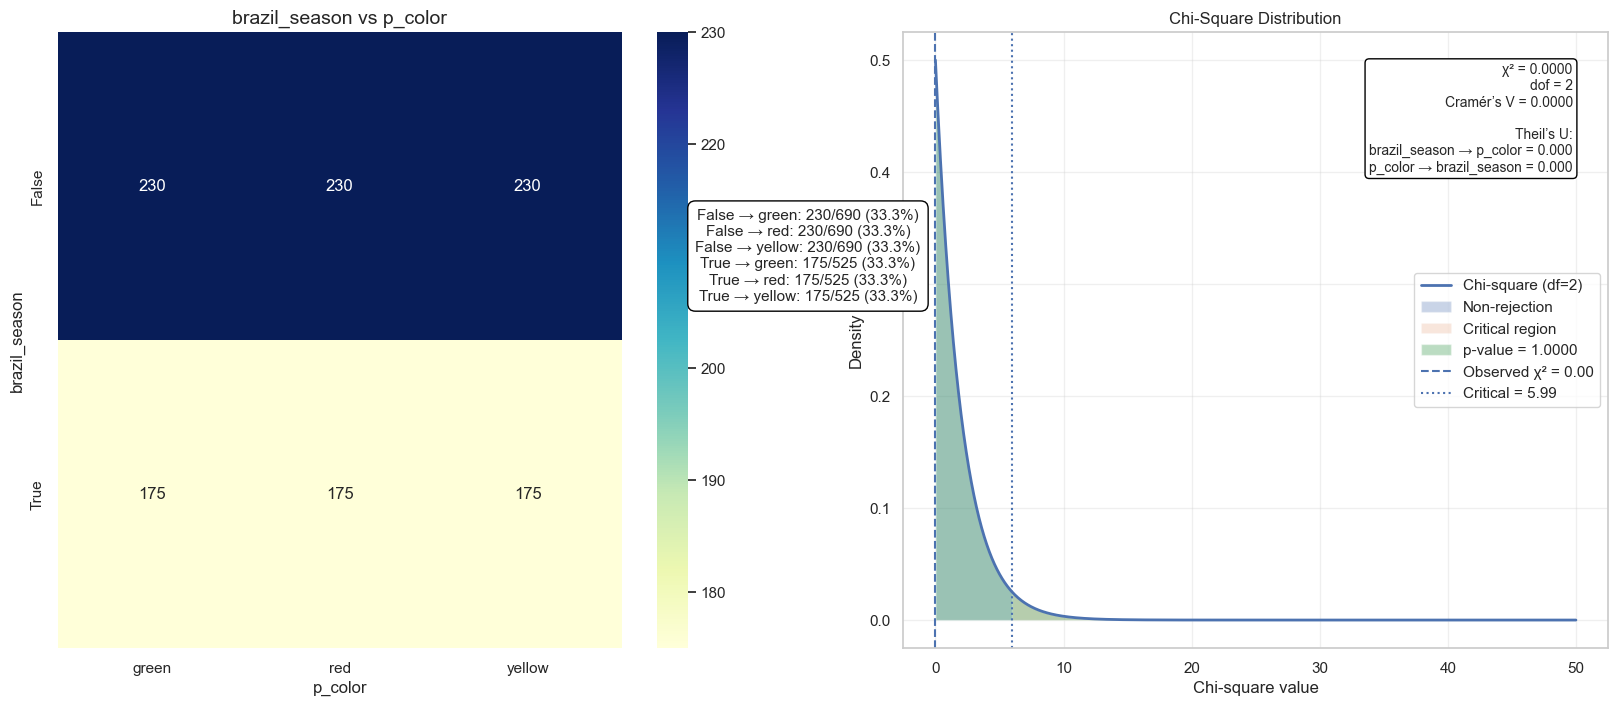


--- FULL SUMMARY ---
Chi-square: 0.0000
p-value: 1.000000
Cramér’s V: 0.0000,---> Weak association
Theil’s U (brazil_season → p_color): 0.0000,---> Little to no predictive power
Theil’s U (p_color → brazil_season): 0.0000,---> Little to no predictive power

Observed:
p_color        green  red  yellow
brazil_season                    
False            230  230     230
True             175  175     175

Expected:
p_color        green    red  yellow
brazil_season                      
False          230.0  230.0   230.0
True           175.0  175.0   175.0

Row %:
p_color        green    red  yellow
brazil_season                      
False          33.33  33.33   33.33
True           33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: No strong evidence of association

Done.

Analyzing association between indonesia_season and p_color


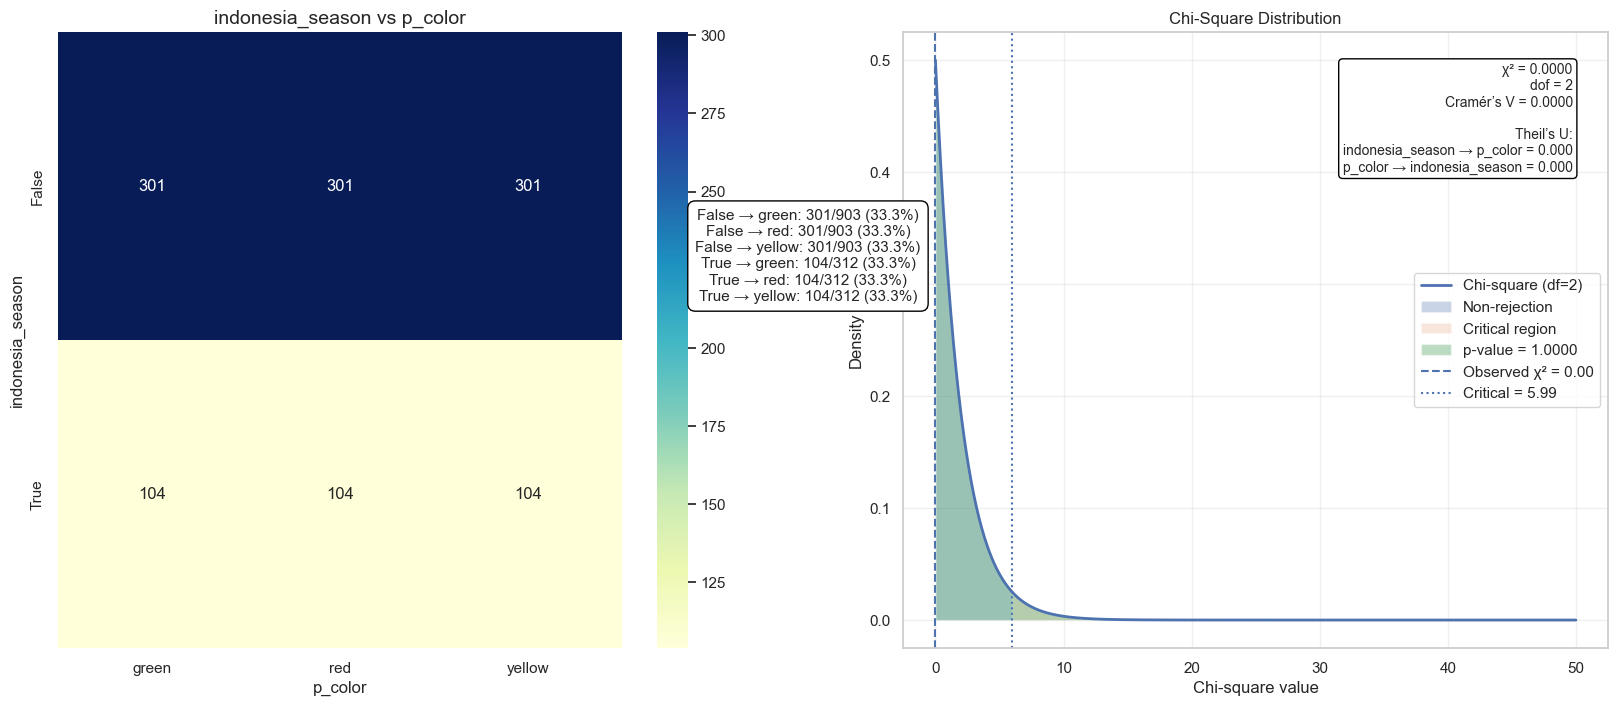


--- FULL SUMMARY ---
Chi-square: 0.0000
p-value: 1.000000
Cramér’s V: 0.0000,---> Weak association
Theil’s U (indonesia_season → p_color): 0.0000,---> Little to no predictive power
Theil’s U (p_color → indonesia_season): 0.0000,---> Little to no predictive power

Observed:
p_color           green  red  yellow
indonesia_season                    
False               301  301     301
True                104  104     104

Expected:
p_color           green    red  yellow
indonesia_season                      
False             301.0  301.0   301.0
True              104.0  104.0   104.0

Row %:
p_color           green    red  yellow
indonesia_season                      
False             33.33  33.33   33.33
True              33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: No strong evidence of association

Done.

Analyzing association between india_s

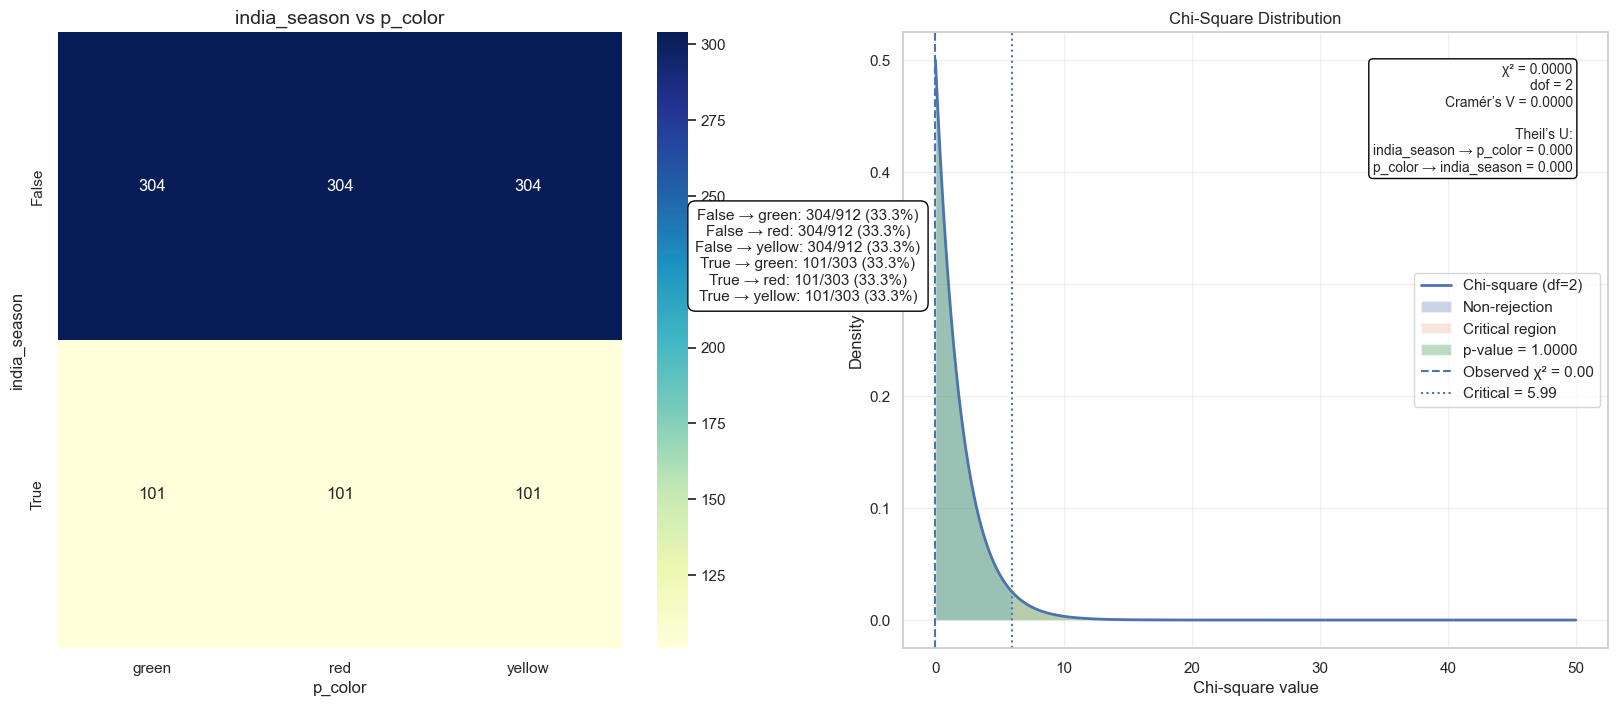


--- FULL SUMMARY ---
Chi-square: 0.0000
p-value: 1.000000
Cramér’s V: 0.0000,---> Weak association
Theil’s U (india_season → p_color): 0.0000,---> Little to no predictive power
Theil’s U (p_color → india_season): 0.0000,---> Little to no predictive power

Observed:
p_color       green  red  yellow
india_season                    
False           304  304     304
True            101  101     101

Expected:
p_color       green    red  yellow
india_season                      
False         304.0  304.0   304.0
True          101.0  101.0   101.0

Row %:
p_color       green    red  yellow
india_season                      
False         33.33  33.33   33.33
True          33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: No strong evidence of association

Done.

Analyzing association between china_season and p_color


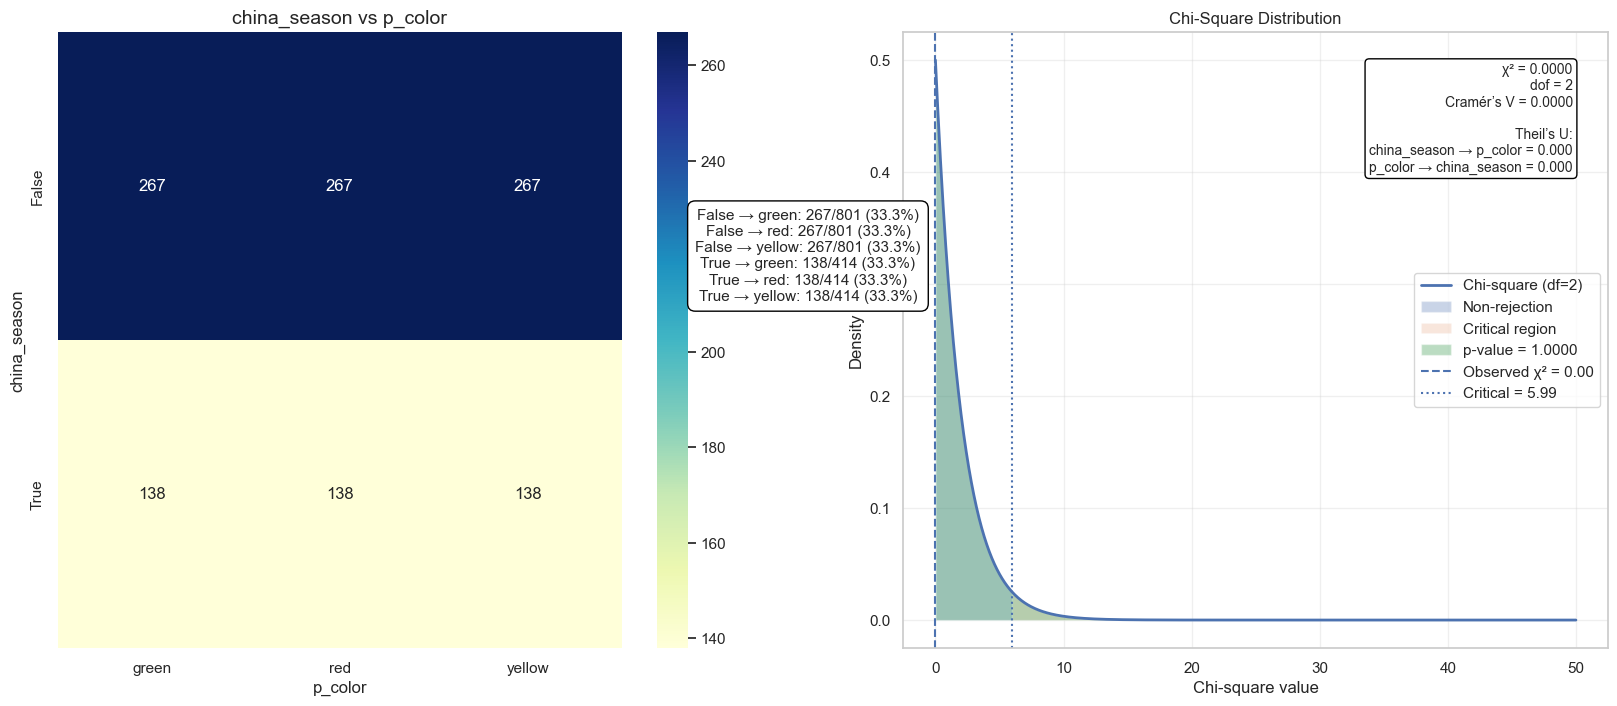


--- FULL SUMMARY ---
Chi-square: 0.0000
p-value: 1.000000
Cramér’s V: 0.0000,---> Weak association
Theil’s U (china_season → p_color): 0.0000,---> Little to no predictive power
Theil’s U (p_color → china_season): 0.0000,---> Little to no predictive power

Observed:
p_color       green  red  yellow
china_season                    
False           267  267     267
True            138  138     138

Expected:
p_color       green    red  yellow
china_season                      
False         267.0  267.0   267.0
True          138.0  138.0   138.0

Row %:
p_color       green    red  yellow
china_season                      
False         33.33  33.33   33.33
True          33.33  33.33   33.33

Cell Contributions:
[False, green] → 0.000
[False, red] → 0.000
[False, yellow] → 0.000
[True, green] → 0.000
[True, red] → 0.000
[True, yellow] → 0.000

Conclusion: No strong evidence of association

Done.



In [11]:
df[boolean_cols]=df[boolean_cols].astype(str)
for col in boolean_cols:
    visualize_categorical_association_advanced(df,col,"p_color", alpha=0.05)